In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from functools import reduce
from scipy.stats import norm, probplot
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

Data Loading

In [2]:
df = pd.read_csv("netflix_titles.csv")
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


Understanding Data

In [3]:
print("Shape of dataset:", df.shape)
df.info()

Shape of dataset: (8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [5]:
df.isna().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


Data Transformation

In [53]:
# Remove special characters from title using regex — keep alphabets, digits, spaces
df["title"] = df["title"].str.replace(r"[^a-zA-Z0-9 ]", "", regex=True)
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show           Blood  Water          Unknown   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans          Unknown   
4      s5  TV Show           Kota Factory          Unknown   

                                                cast        country  \
0                                      Not Available  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...        Unknown   
3                                      Not Available        Unknown   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

   date_added  release_year rating   duration  \
0  2021-09-25          2020  PG-13     90 min   
1  2021-09-24          2021  TV-MA  2 Seasons   
2  2021-09-24          2021  TV-MA   1 Season   
3  2

In [57]:
# Fill missing values
df["director"]   = df["director"].fillna("Unknown")
df["cast"]       = df["cast"].fillna("Not Available")
df["country"]    = df["country"].fillna("Unknown")
df["rating"]     = df["rating"].fillna(df["rating"].mode()[0])
df["duration"]   = df["duration"].fillna("0 min")
df["date_added"] = df["date_added"].fillna("").astype(str).str.strip()
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,month_name,duration_int
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,Sep,90.0
1,s2,TV Show,Blood Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,Sep,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,Sep,1.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9,Sep,1.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9,Sep,2.0


In [15]:
# Parse date column and extract year / month  (DateTime)
df["date_added"]  = pd.to_datetime(df["date_added"], format="%B %d, %Y", errors="coerce")
df["year_added"]  = df["date_added"].dt.year.astype("Int64")
df["month_added"] = df["date_added"].dt.month.astype("Int64")
df["month_name"]  = df["date_added"].dt.strftime("%b")
df[["date_added", "year_added", "month_added"]].head()

,date_added,year_added,month_added
0,2021-09-25,2021,9
1,2021-09-24,2021,9
2,2021-09-24,2021,9
3,2021-09-24,2021,9
4,2021-09-24,2021,9


In [16]:
# Extract numeric duration using regex
df["duration_int"] = df["duration"].str.extract(r"(\d+)").astype(float)

# Downcast numeric columns to save memory
df["release_year"] = pd.to_numeric(df["release_year"], downcast="integer", errors="coerce")
df["duration_int"] = pd.to_numeric(df["duration_int"],  downcast="float",   errors="coerce")
df[["release_year", "duration_int"]].dtypes

,0
release_year,int16
duration_int,float32


In [17]:
# HOF — map, filter, reduce on movie durations
movies = df[df["type"] == "Movie"].copy()
shows  = df[df["type"] == "TV Show"].copy()

# map : convert minutes → hours
print("Duration in hours (first 5):")
print(list(map(lambda x: round(x / 60, 2), movies["duration_int"].dropna()))[:5])

# filter : movies longer than average
avg_dur = movies["duration_int"].mean()
long_movies = list(filter(lambda x: x > avg_dur, movies["duration_int"].dropna()))
print(f"\nMovies longer than avg ({avg_dur:.1f} min): {len(long_movies)}")

# reduce : longest movie duration
durations = movies["duration_int"].dropna().tolist()
longest = reduce(lambda x, y: x if x > y else y, durations)
print(f"\nLongest movie: {longest:.0f} min")

Duration in hours (first 5):
[1.5, 1.52, 2.08, 1.73, 2.12]

Movies longer than avg (99.5 min): 2922

Longest movie: 312 min


Data Aggregation

In [18]:
# Count of content by type
print(df.groupby("type")["show_id"].count())

type
Movie      6131
TV Show    2676
Name: show_id, dtype: int64


In [19]:
# Average movie duration per rating
print(movies.groupby("rating")["duration_int"].mean().round(2).sort_values(ascending=False))

rating
NC-17       125.000000
TV-14       110.290001
PG-13       108.330002
R           106.720001
UR          106.330002
PG           98.279999
TV-MA        95.870003
TV-PG        94.849998
NR           94.529999
G            90.269997
TV-G         79.669998
TV-Y7-FV     68.400002
TV-Y7        66.290001
TV-Y         48.110001
66 min        0.000000
84 min        0.000000
74 min        0.000000
Name: duration_int, dtype: float32


In [20]:
# Content count by country and type
country_type = df.groupby(["country", "type"])["show_id"].count().unstack().fillna(0)
print(country_type.nlargest(10, "Movie"))

type             Movie  TV Show
country                        
United States   2058.0    760.0
India            893.0     79.0
Unknown          440.0    391.0
United Kingdom   206.0    213.0
Canada           122.0     59.0
Spain             97.0     48.0
Egypt             92.0     14.0
Nigeria           86.0      9.0
Indonesia         77.0      2.0
Japan             76.0    169.0


In [21]:
# Total titles added per year
print(df.groupby("year_added")["show_id"].count().sort_index())

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: show_id, dtype: int64


In [22]:
# Top 5 longest movies
print(movies.nlargest(5, "duration_int")[["title", "duration_int"]])

                           title  duration_int
4253   Black Mirror Bandersnatch         312.0
717   Headspace Unwind Your Mind         273.0
2491      The School of Mischief         253.0
2487              No Longer kids         237.0
2484          Lock Your Girls In         233.0


In [23]:
# Short movies — below average duration
print(movies[movies["duration_int"] < movies["duration_int"].mean()][["title", "duration_int"]].head())

                                                title  duration_int
0                                Dick Johnson Is Dead          90.0
6                     My Little Pony A New Generation          91.0
13                   Confessions of an Invisible Girl          91.0
16  Europes Most Dangerous Man Otto Skorzeny in Spain          67.0
18                                          Intrusion          94.0


In [24]:
# Top 10 most prolific directors  (excluding unknown)
print(df[df["director"] != "Unknown"]["director"].value_counts().head(10))

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Youssef Chahine           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64


In [25]:
# Count content by country
print(df["country"].value_counts().head(10))

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


EDA

In [26]:
# Descriptive statistics for movie duration
print("Mean   :", round(movies["duration_int"].mean(), 2))
print("Median :", round(movies["duration_int"].median(), 2))
print("Mode   :", movies["duration_int"].mode()[0])
print("Std Dev:", round(movies["duration_int"].std(), 2))
print("Variance:", round(movies["duration_int"].var(), 2))

Mean   : 99.53
Median : 98.0
Mode   : 90.0
Std Dev: 28.37
Variance: 804.82


In [27]:
# Unique value counts
print("Unique content types :", df["type"].nunique())
print("Unique ratings       :", df["rating"].nunique())
print("Unique countries     :", df["country"].nunique())
print("Unique directors     :", df["director"].nunique())

Unique content types : 2
Unique ratings       : 17
Unique countries     : 749
Unique directors     : 4529


In [28]:
# Skewness and kurtosis — normality check
print("Skewness:", round(movies["duration_int"].skew(), 2))
print("Kurtosis:", round(movies["duration_int"].kurt(), 2))

Skewness: 0.18
Kurtosis: 2.31


In [29]:
# Correlation between numeric columns
num_df = df[["release_year", "duration_int", "year_added", "month_added"]]
print(num_df.corr().round(4))

              release_year  duration_int  year_added  month_added
release_year        1.0000       -0.2491      0.1115      -0.0392
duration_int       -0.2491        1.0000      0.0301      -0.0174
year_added          0.1115        0.0301      1.0000      -0.1604
month_added        -0.0392       -0.0174     -0.1604       1.0000


In [30]:
# Range of movie durations
print("Range:", movies["duration_int"].max() - movies["duration_int"].min(), "min")

Range: 312.0 min


In [31]:
# Outlier detection using IQR
Q1  = movies["duration_int"].quantile(0.25)
Q3  = movies["duration_int"].quantile(0.75)
IQR = Q3 - Q1

outliers = movies[(movies["duration_int"] < Q1 - 1.5*IQR) | (movies["duration_int"] > Q3 + 1.5*IQR)]
print(f"Outliers: {len(outliers)} movies ({round(len(outliers)/len(movies)*100, 1)}%)")

Outliers: 453 movies (7.4%)


Visualization

/tmp/ipykernel_3064/3847179263.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="type", data=df, palette=["#e50914", "#564d4d"])


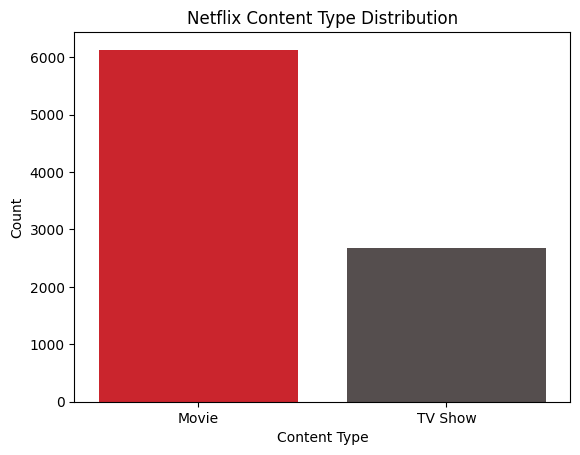

In [32]:
# Univariate Analysis
# Content type distribution
sns.countplot(x="type", data=df, palette=["#e50914", "#564d4d"])
plt.title("Netflix Content Type Distribution")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

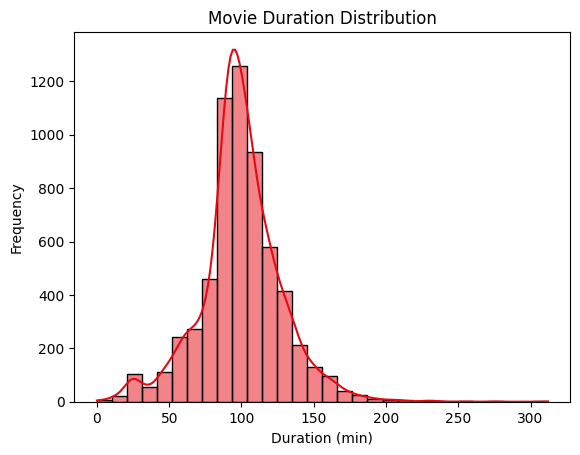

In [33]:
# Univariate Analysis
# Movie duration — histogram + KDE
sns.histplot(movies["duration_int"].dropna(), kde=True, bins=30, color="#e50914")
plt.title("Movie Duration Distribution")
plt.xlabel("Duration (min)")
plt.ylabel("Frequency")
plt.show()

/tmp/ipykernel_3064/552105218.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="rating", data=df, order=order, palette="magma")


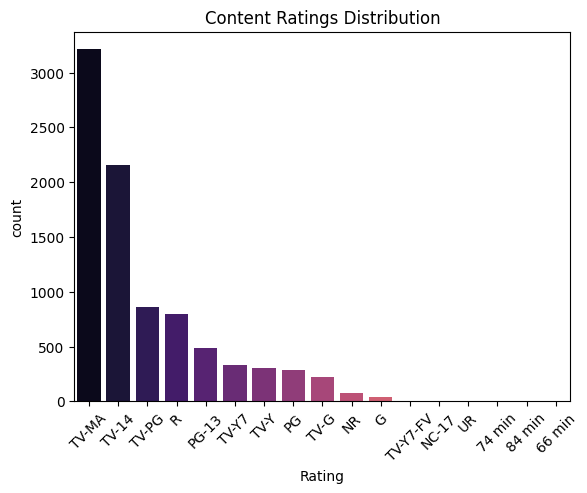

In [34]:
# Univariate Analysis
# Ratings countplot
order = df["rating"].value_counts().index
sns.countplot(x="rating", data=df, order=order, palette="magma")
plt.title("Content Ratings Distribution")
plt.xlabel("Rating")
plt.xticks(rotation=45)
plt.show()

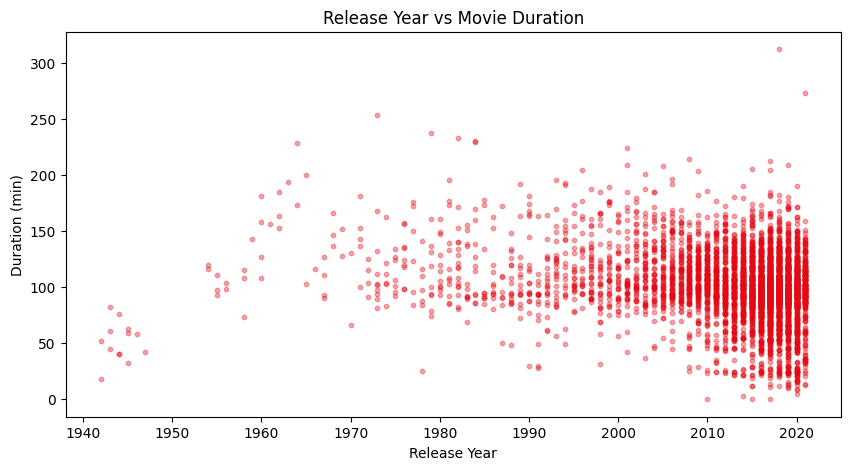

In [35]:
# Bivariate Analysis
# Scatter — release year vs movie duration
plt.figure(figsize=(10, 5))
plt.scatter(movies["release_year"], movies["duration_int"], alpha=0.35, color="#e50914", s=10)
plt.title("Release Year vs Movie Duration")
plt.xlabel("Release Year")
plt.ylabel("Duration (min)")
plt.show()

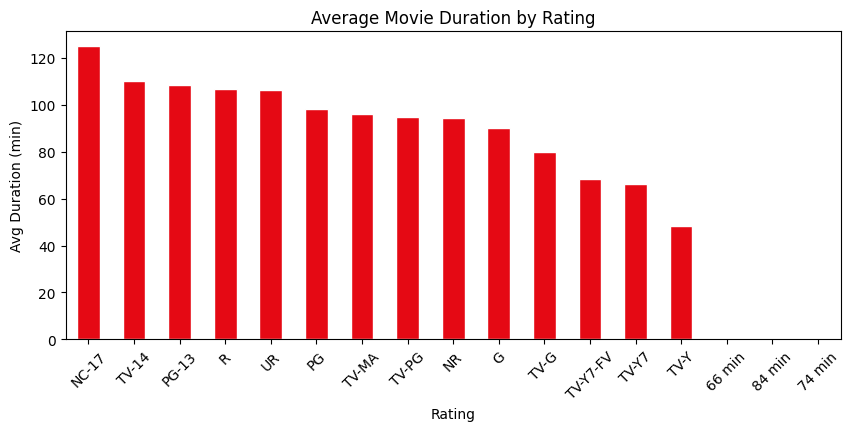

In [36]:
# Bivariate Analysis
# Average movie duration per rating
avg_by_rating = movies.groupby("rating")["duration_int"].mean().sort_values(ascending=False)
avg_by_rating.plot(kind="bar", color="#e50914", figsize=(10, 4), edgecolor="white")
plt.title("Average Movie Duration by Rating")
plt.xlabel("Rating")
plt.ylabel("Avg Duration (min)")
plt.xticks(rotation=45)
plt.show()

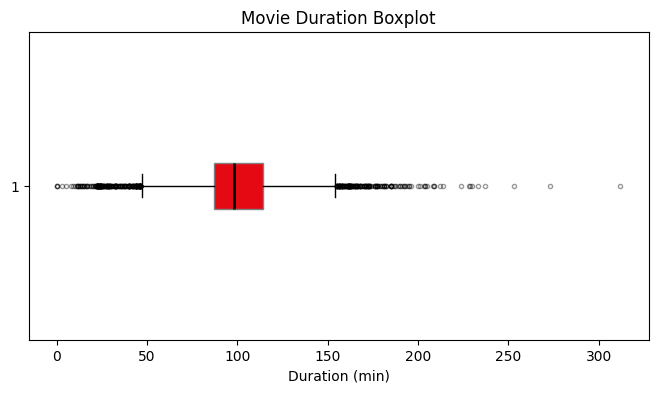

/tmp/ipykernel_3064/3053751583.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="rating", y="duration_int", data=movies[movies["rating"].isin(top8)],


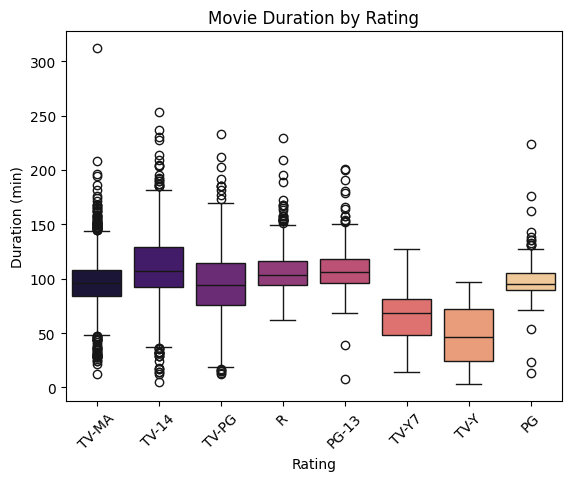

In [37]:
# Outliers
# Boxplot of movie duration
plt.figure(figsize=(8, 4))
plt.boxplot(movies["duration_int"].dropna(), vert=False, patch_artist=True,
            boxprops=dict(facecolor="#e50914", color="gray"),
            medianprops=dict(color="black", linewidth=2),
            flierprops=dict(marker="o", color="#e50914", alpha=0.4, markersize=3))
plt.title("Movie Duration Boxplot")
plt.xlabel("Duration (min)")
plt.show()

# Boxplot by top 8 ratings
top8 = df["rating"].value_counts().head(8).index
sns.boxplot(x="rating", y="duration_int", data=movies[movies["rating"].isin(top8)],
            order=top8, palette="magma")
plt.title("Movie Duration by Rating")
plt.xlabel("Rating")
plt.ylabel("Duration (min)")
plt.xticks(rotation=45)
plt.show()

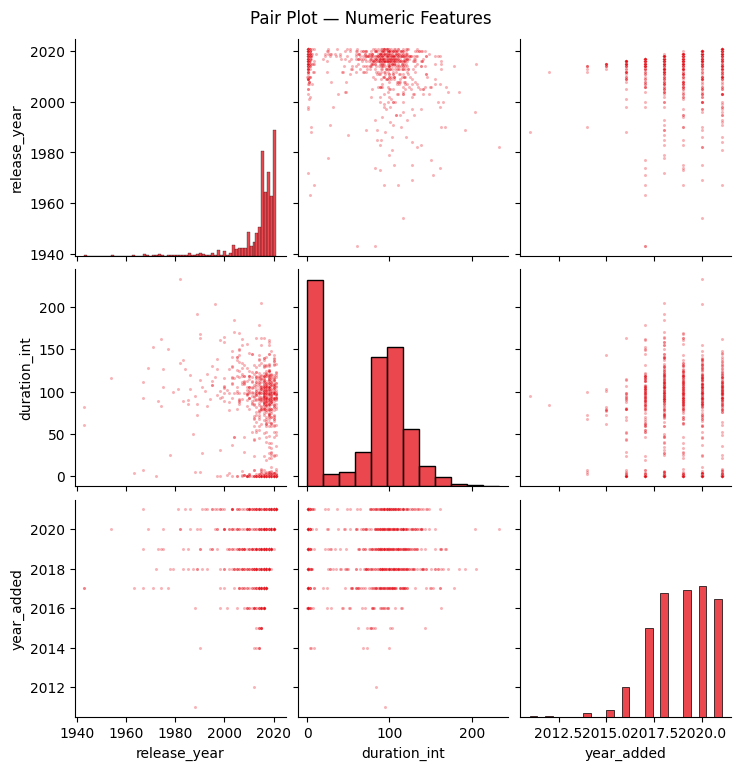

In [38]:
# Multivariate Analysis
# Pair plot
sns.pairplot(df[["release_year", "duration_int", "year_added"]].dropna().sample(1000, random_state=42),
             plot_kws={"alpha": 0.3, "s": 5, "color": "#e50914"},
             diag_kws={"color": "#e50914"})
plt.suptitle("Pair Plot — Numeric Features", y=1.02)
plt.show()

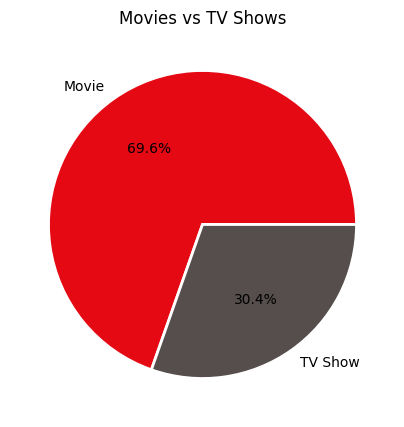

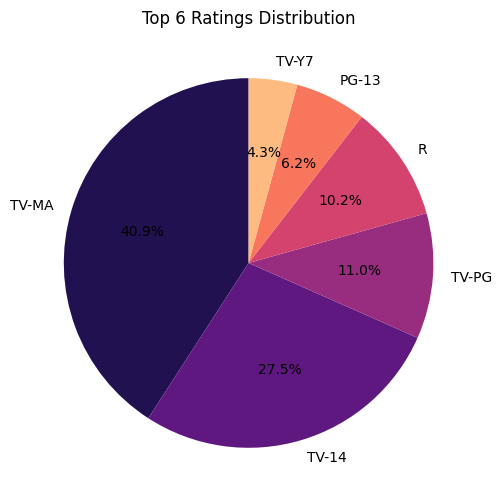

In [39]:
# Pie Chart
# Content type split
counts1 = df["type"].value_counts()
plt.figure(figsize=(5, 5))
plt.pie(counts1, labels=counts1.index, autopct="%1.1f%%",
        colors=["#e50914", "#564d4d"],
        wedgeprops={"edgecolor": "white", "linewidth": 2})
plt.title("Movies vs TV Shows")
plt.show()

# Top 6 ratings
counts2 = df["rating"].value_counts().head(6)
plt.figure(figsize=(6, 6))
plt.pie(counts2, labels=counts2.index, autopct="%1.1f%%", startangle=90,
        colors=sns.color_palette("magma", 6))
plt.title("Top 6 Ratings Distribution")
plt.show()

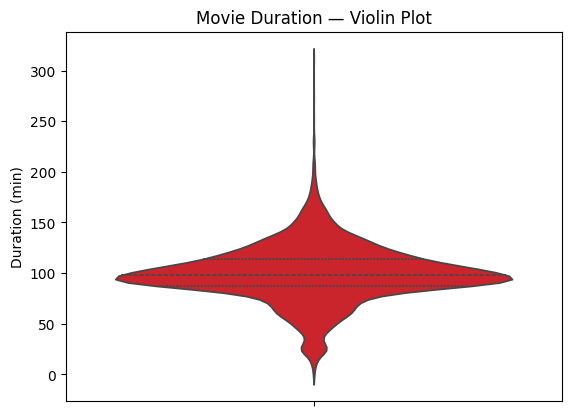

In [40]:
# Violin Plot
sns.violinplot(y=movies["duration_int"].dropna(), color="#e50914", inner="quartile")
plt.title("Movie Duration — Violin Plot")
plt.ylabel("Duration (min)")
plt.show()

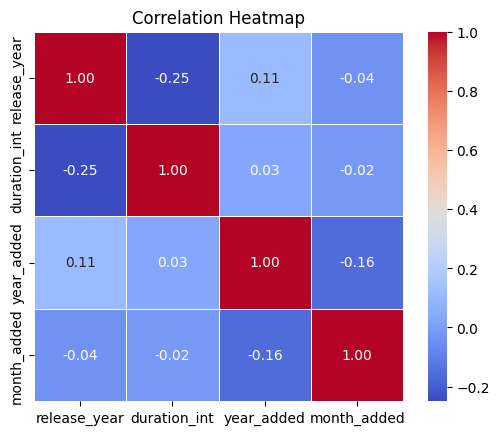

In [41]:
# Correlation heatmap
corr = df[["release_year", "duration_int", "year_added", "month_added"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, square=True)
plt.title("Correlation Heatmap")
plt.show()

/tmp/ipykernel_3064/2162829968.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")


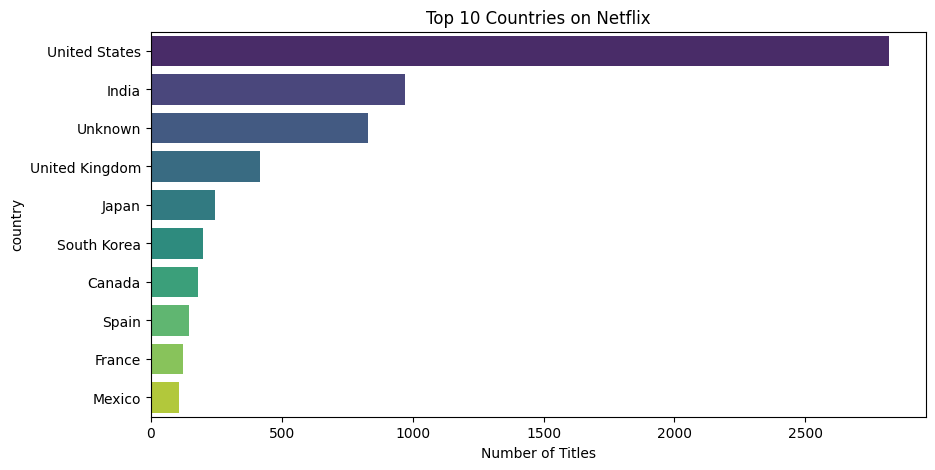

In [42]:
# Top 10 countries producing content
top_countries = df["country"].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")
plt.title("Top 10 Countries on Netflix")
plt.xlabel("Number of Titles")
plt.show()

/tmp/ipykernel_3064/799424896.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette="magma")


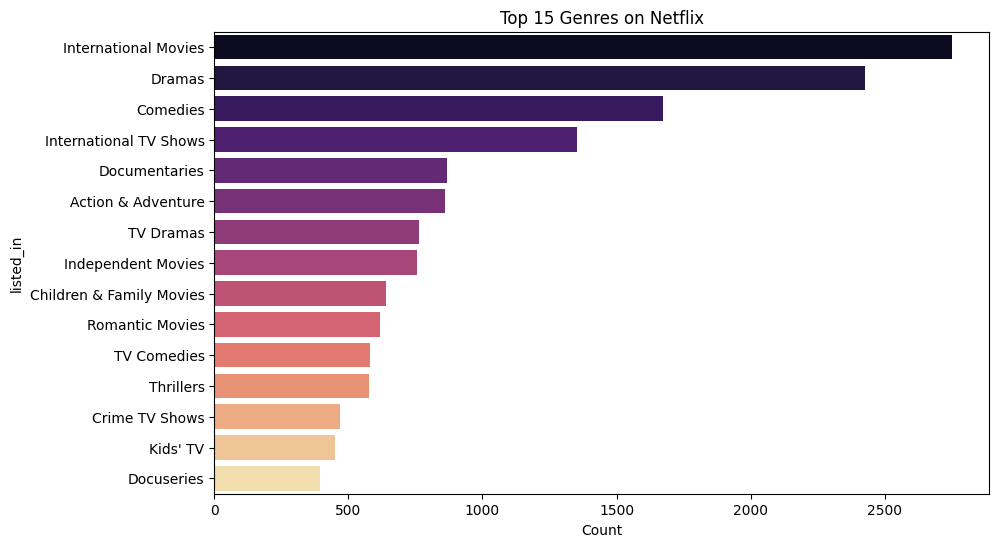

In [43]:
# Top 15 genres — explode multi-genre column
genre_series = df["listed_in"].str.split(",").explode().str.strip()
top_genres = genre_series.value_counts().head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette="magma")
plt.title("Top 15 Genres on Netflix")
plt.xlabel("Count")
plt.show()

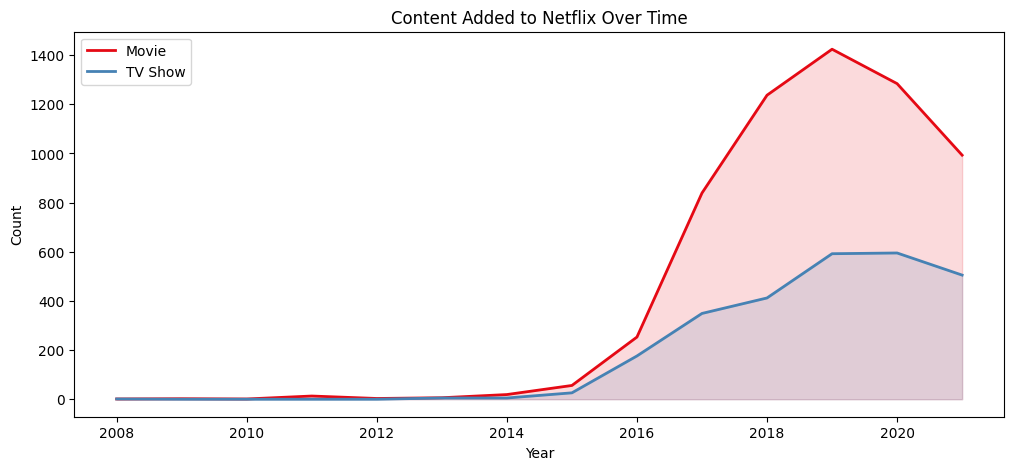

In [44]:
# Content added per year — area / line chart
year_type = pd.crosstab(df["year_added"], df["type"]).dropna()
plt.figure(figsize=(12, 5))
plt.plot(year_type.index, year_type.get("Movie",   0), label="Movie",   color="#e50914", linewidth=2)
plt.plot(year_type.index, year_type.get("TV Show", 0), label="TV Show", color="steelblue", linewidth=2)
plt.fill_between(year_type.index, year_type.get("Movie",   0), alpha=0.15, color="#e50914")
plt.fill_between(year_type.index, year_type.get("TV Show", 0), alpha=0.15, color="steelblue")
plt.title("Content Added to Netflix Over Time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend()
plt.show()

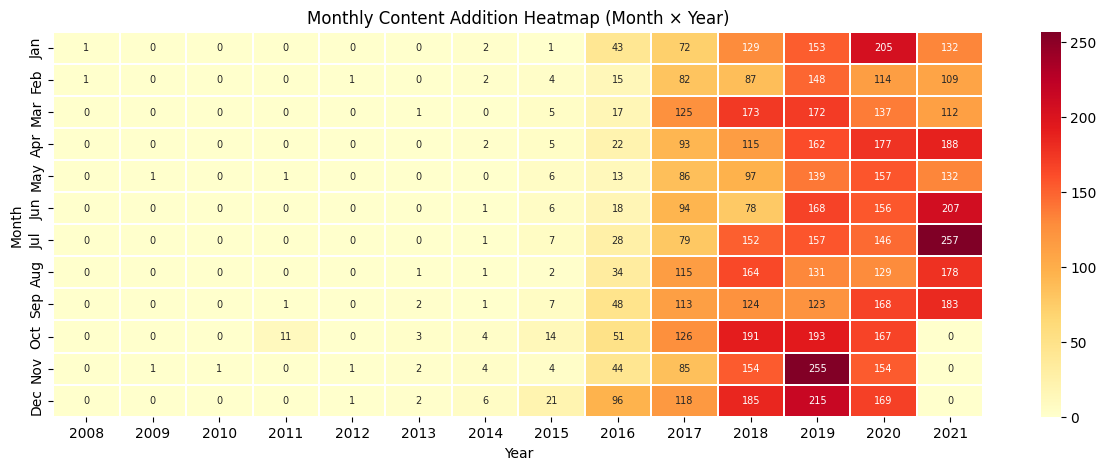

In [45]:
# Monthly content addition heatmap
month_year = pd.crosstab(df["month_added"].dropna().astype(int),
                         df["year_added"].dropna().astype(int))
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
month_year.index = [month_labels[i-1] for i in month_year.index]
plt.figure(figsize=(15, 5))
sns.heatmap(month_year, cmap="YlOrRd", annot=True, fmt="g",
            linewidths=0.3, annot_kws={"size": 7})
plt.title("Monthly Content Addition Heatmap (Month × Year)")
plt.xlabel("Year")
plt.ylabel("Month")
plt.show()

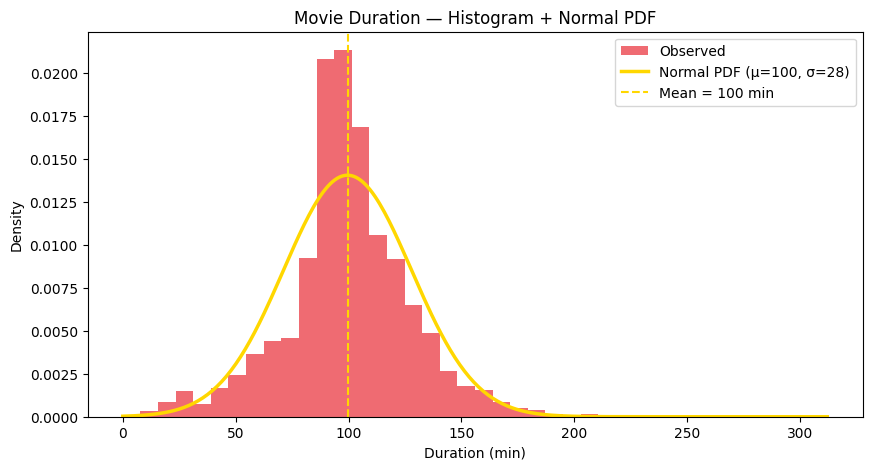

In [46]:
# Probability Distribution — Normal PDF overlay on duration histogram
dur = movies["duration_int"].dropna()
mu, sigma = dur.mean(), dur.std()
x = np.linspace(dur.min(), dur.max(), 300)
pdf_vals = norm.pdf(x, mu, sigma)

plt.figure(figsize=(10, 5))
plt.hist(dur, bins=40, density=True, color="#e50914", alpha=0.6, label="Observed")
plt.plot(x, pdf_vals, color="gold", linewidth=2.5, label=f"Normal PDF (μ={mu:.0f}, σ={sigma:.0f})")
plt.axvline(mu, color="gold", linestyle="--", linewidth=1.5, label=f"Mean = {mu:.0f} min")
plt.title("Movie Duration — Histogram + Normal PDF")
plt.xlabel("Duration (min)")
plt.ylabel("Density")
plt.legend()
plt.show()

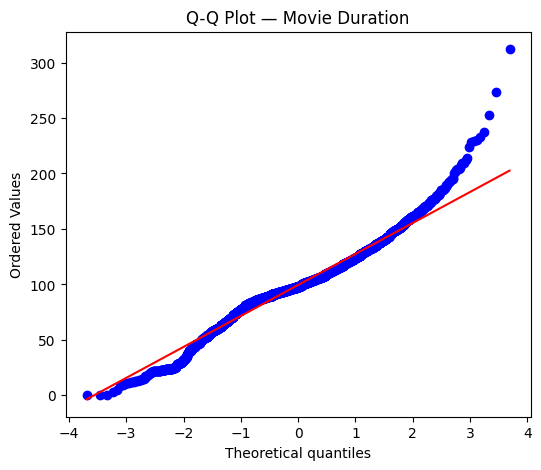

In [47]:
# Q-Q Plot — normality check
fig, ax = plt.subplots(figsize=(6, 5))
probplot(movies["duration_int"].dropna(), plot=ax)
ax.set_title("Q-Q Plot — Movie Duration")
plt.show()

Modelling

In [48]:
# Encode categorical features for modelling
df_model = movies[["release_year", "duration_int", "year_added", "month_added", "rating"]].dropna().copy()

le = LabelEncoder()
df_model["rating_enc"] = le.fit_transform(df_model["rating"])

# Features and target
X = df_model[["release_year", "year_added", "month_added", "rating_enc"]]
y = df_model["duration_int"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("MSE    :", round(mean_squared_error(y_test, y_pred), 2))
print("R² Score:", round(r2_score(y_test, y_pred), 4))

MSE    : 686.89
R² Score: 0.074


R² Score: 0.0142
Duration = 1408.16 + (-0.6501 * release_year)


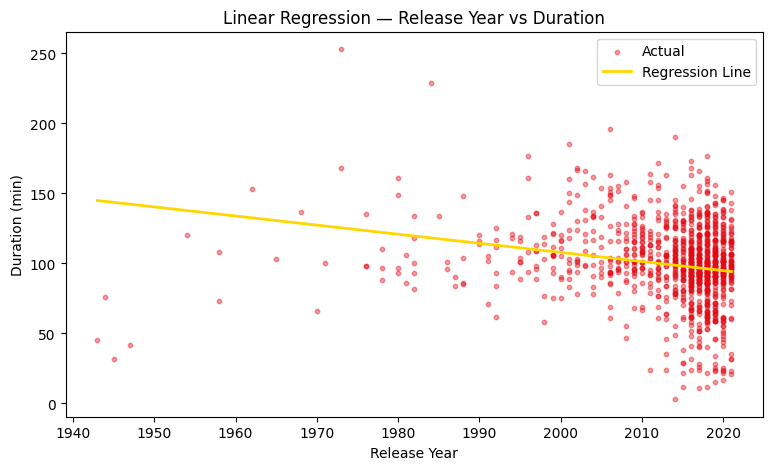

In [49]:
# Simple Linear Regression — release_year vs duration
X_simple = movies[["release_year"]].dropna()
y_simple  = movies.loc[X_simple.index, "duration_int"].dropna()
X_simple  = X_simple.loc[y_simple.index]

X_train, X_test, y_train, y_test = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)
y_pred_simple = model_simple.predict(X_test)

slope     = model_simple.coef_[0]
intercept = model_simple.intercept_

print(f"R² Score: {r2_score(y_test, y_pred_simple):.4f}")
print(f"Duration = {intercept:.2f} + ({slope:.4f} * release_year)")

# Plot regression line
plt.figure(figsize=(9, 5))
plt.scatter(X_test, y_test, color="#e50914", alpha=0.4, s=10, label="Actual")
plt.plot(X_test.sort_values("release_year"),
         model_simple.predict(X_test.sort_values("release_year")),
         color="gold", linewidth=2, label="Regression Line")
plt.title("Linear Regression — Release Year vs Duration")
plt.xlabel("Release Year")
plt.ylabel("Duration (min)")
plt.legend()
plt.show()

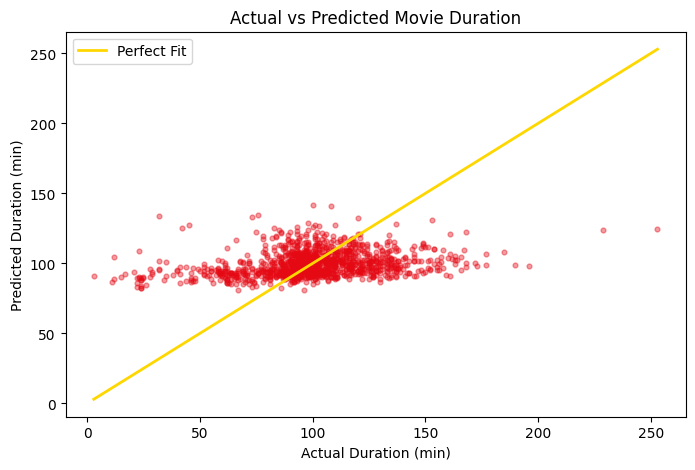

In [50]:
# Actual vs Predicted — multi-feature model
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.4, color="#e50914", s=12)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color="gold", linewidth=2, label="Perfect Fit")
plt.title("Actual vs Predicted Movie Duration")
plt.xlabel("Actual Duration (min)")
plt.ylabel("Predicted Duration (min)")
plt.legend()
plt.show()

# Netflix Data Analysis

Project uploaded to GitHub.